In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from scipy.integrate import quad
from scipy.interpolate import interp1d

from scipy.special import kn

import matplotlib.pyplot as plt

## Compute equation (C.18) of 2206.13530

In [2]:
def G_integrand(t, x, zeta):
    return 2 * t * np.nan_to_num(
          np.power(np.expm1(x * np.sqrt(t**2 + 1)), -1)
        * np.log(
            (np.exp(0.5 * x * (np.sqrt(t**2 + 1) + t)) + zeta)
            / (np.exp(0.5 * x * np.sqrt(t**2 + 1)) + zeta * np.exp(0.5 * x * t))
        )
    )

In [3]:
def G_small_x_fermi(x):
    return np.log(2)*(np.pi**2)/(6*x**2)

In [15]:
#G diverges as x goes to zero but has a pretty simple asymptotic expansion
#stitch together the expansion with the numerical integrals
x_range = np.geomspace(1e-3, 100, 10000)

G_fermion_table = np.array(
    [quad(G_integrand, 0, np.inf, args=(x, 1), epsrel=1e-12, limit=200)[0] for x in x_range]
)

In [16]:
G_fermion_interp = interp1d(x_range, G_fermion_table, bounds_error=False, fill_value=0)

In [30]:
np.savez_compressed('../input/Gfun_fermion.npz',
                    x_range=x_range,
                    G_fermion_table=G_fermion_table
                   )

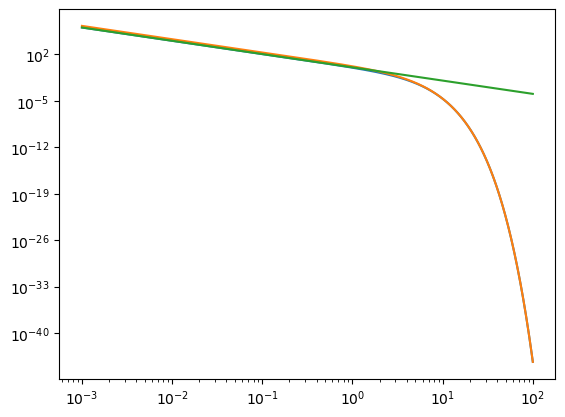

In [21]:
plt.plot(x_range, G_fermion_interp(x_range))
plt.plot(x_range, kn(2, x_range))
plt.plot(x_range, G_small_x_fermi(x_range))
plt.yscale('log')
plt.xscale('log')

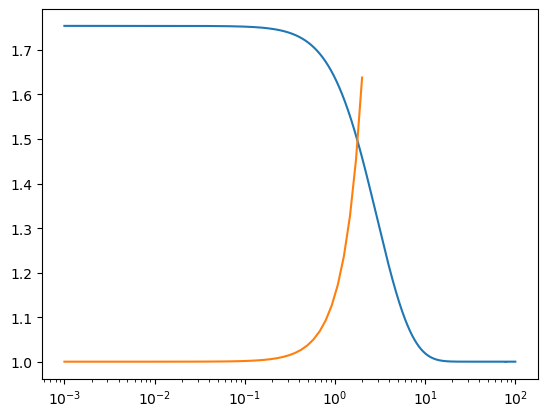

In [26]:
plt.plot(x_range, kn(2, x_range)/G_fermion_interp(x_range))
plt.plot(np.geomspace(1e-3, 2), G_small_x_fermi(np.geomspace(1e-3, 2))/G_fermion_interp(np.geomspace(1e-3, 2)))
plt.xscale('log')

In [27]:
def G_fermion(x):
    x = np.atleast_1d(x)

    mask_small_x = np.where(x < 1e-2)
    mask_large_x = np.where(x > 20)
dis
    res = np.zeros(len(x))

    res = G_fermion_interp(x)
    res[mask_small_x] = G_small_x_fermi(x[mask_small_x])
    res[mask_large_x] = kn(2, x[mask_large_x])

    return res

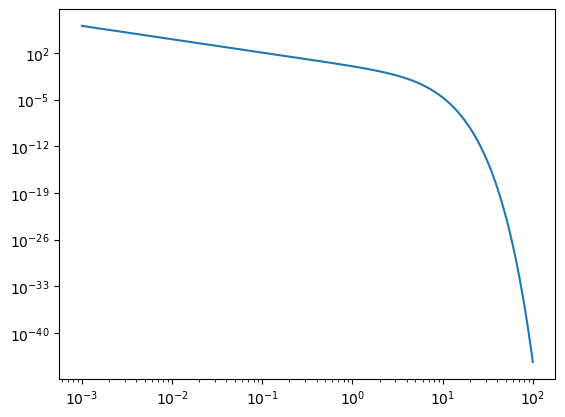

In [29]:
plt.plot(x_range, G_fermion(x_range))
plt.xscale('log')
plt.yscale('log')